In [1]:
%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import re

In [2]:
# ========= 1. 設定 (Configuration) =========

base_dir = r"C:\experiment\1D"

experiments = [
    {"file": os.path.join(base_dir, "t0103", "t0103v2.csv"), "group_val":  5, "group": "5cm"},
    {"file": os.path.join(base_dir, "t0104", "t0104.csv"), "group_val":  7, "group": "7cm"},
    {"file": os.path.join(base_dir, "t0105", "t0105.csv"), "group_val": 10, "group": "10cm"},
    {"file": os.path.join(base_dir, "t0106", "t0106.csv"), "group_val": 12, "group": "12cm"},
    {"file": os.path.join(base_dir, "t0100", "t0100v2.csv"), "group_val": 15, "group": "15cm"},
    {"file": os.path.join(base_dir, "t0107", "t0107.csv"), "group_val": 15, "group": "15cm"},
]

# 繪圖 X 軸 (Normal Stress) 範圍
xlim_min = 10
xlim_max = 34


In [3]:
# ========= 2. 資料處理 (Data Processing) =========

def extract_sigma(run_name):
    """ 從 run1_32MPa 這樣的字串中提取 32 作數值 """
    match = re.search(r'_(\d+)MPa', str(run_name))
    if match:
        return float(match.group(1))
    return np.nan


def process_data(target_metric):
    """ 讀取 CSV 並合併相同 group 後計算在每個 sigma 下的 median 與 IQR """
    all_dfs = []
    for exp in experiments:
        import os
        import pandas as pd
        if not os.path.exists(exp['file']):
            print(f"找不到檔案: {exp['file']}")
            continue

        df = pd.read_csv(exp['file'])

        if 'skipped' in df.columns:
            df = df[df['skipped'] != 'YES'].copy()

        if target_metric == 'k' and 'k' in df.columns:
            df = df[pd.to_numeric(df['k'], errors='coerce') >= 0]

        if target_metric == 'delta_mu' and 'delta_mu' in df.columns:
            df['delta_mu'] = df['delta_mu'] * (250 / (5 * exp['group_val']))

        if target_metric not in df.columns:
            continue

        df['sigma'] = df['Run'].apply(extract_sigma)
        df = df.dropna(subset=['sigma', target_metric])
        df['group'] = exp['group']
        df['group_val'] = exp['group_val']
        all_dfs.append(df)

    if not all_dfs:
        return []

    combined_df = pd.concat(all_dfs, ignore_index=True)
    processed_data = []
    for (grp, grp_val), grp_df in combined_df.groupby(['group', 'group_val'], sort=False):
        stats = grp_df.groupby('sigma')[target_metric].agg(
            median='median',
            q1=lambda x: x.quantile(0.25),
            q3=lambda x: x.quantile(0.75)
        ).reset_index()

        processed_data.append({
            'group': grp,
            'group_val': grp_val,
            'stats': stats
        })
    processed_data.sort(key=lambda x: x['group_val'])
    return processed_data

def process_delta_data():
    """
    讀取 CSV，合併相同 group，計算 delta：
    1. 每筆資料計算 delta_E2、delta_E3、delta_E4 的平均
    2. 按 sigma 分組，計算中位數與 IQR
    """
    all_dfs = []
    for exp in experiments:
        import os
        import pandas as pd
        if not os.path.exists(exp['file']):
            print(f"找不到檔案: {exp['file']}")
            continue

        df = pd.read_csv(exp['file'])

        if 'skipped' in df.columns:
            df = df[df['skipped'] != 'YES'].copy()

        required_cols = ['delta_E2', 'delta_E3', 'delta_E4']
        if not all(c in df.columns for c in required_cols):
            continue

        for c in required_cols:
            df[c] = pd.to_numeric(df[c], errors='coerce')

        df = df.dropna(subset=required_cols)
        df['delta_avg'] = df[required_cols].mean(axis=1)

        df['sigma'] = df['Run'].apply(extract_sigma)
        df = df.dropna(subset=['sigma', 'delta_avg'])

        df['group'] = exp['group']
        df['group_val'] = exp['group_val']
        all_dfs.append(df)

    if not all_dfs:
        return []

    combined_df = pd.concat(all_dfs, ignore_index=True)
    processed_data = []

    for (grp, grp_val), grp_df in combined_df.groupby(['group', 'group_val'], sort=False):
        stats = grp_df.groupby('sigma')['delta_avg'].agg(
            median='median',
            q1=lambda x: x.quantile(0.25),
            q3=lambda x: x.quantile(0.75)
        ).reset_index()

        processed_data.append({
            'group': grp,
            'group_val': grp_val,
            'stats': stats
        })

    processed_data.sort(key=lambda x: x['group_val'])
    return processed_data


In [4]:
# ========= 3. Publication-Quality Plotting (1D) =========
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.ticker import ScalarFormatter, NullFormatter
from scipy.optimize import curve_fit

PALETTE = ['#C96354', '#338EC4', '#E79F52', '#4D9D71', '#9391C1', '#8CADBD', '#FFE3A7', '#F170AC']
MARKERS = ['o', 's', '^', 'D', 'h', 'P', 'X', 'v']
ALPHA = 1.0

def _apply_pub_style(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(1.2)
    ax.spines['bottom'].set_linewidth(1.2)
    ax.tick_params(axis='both', which='both', direction='out', top=False, right=False, labelsize=11, width=1.0)
    ax.xaxis.label.set_fontsize(13)
    ax.yaxis.label.set_fontsize(13)
    ax.title.set_fontsize(14)
    ax.title.set_fontweight('bold')

def _style_colorbar(cbar, labels, label_text):
    cbar.set_label(label_text, fontsize=12, labelpad=8)
    cbar.ax.set_yticklabels(labels, fontsize=10)
    cbar.ax.tick_params(size=0)
    cbar.outline.set_linewidth(0.8)

def _errorbar_with_alpha(ax, x, y, yerr, color, marker, alpha=ALPHA):
    container = ax.errorbar(
        x, y, yerr=yerr,
        fmt=marker, color=color,
        markersize=5, capsize=6,
        markeredgecolor=color, markerfacecolor=color,
        markeredgewidth=1.3, capthick=1.3, elinewidth=1.3,
        zorder=4,
        alpha=alpha
    )
    return container

def _fit_power_law(ax, x, y, color, alpha=ALPHA):
    def power_law(xv, a, b): return a * (xv ** b)
    slope_init, intercept_init = np.polyfit(np.log(x), np.log(y), 1)
    p0 = [np.exp(intercept_init), slope_init]
    try: popt, _ = curve_fit(power_law, x, y, p0=p0, maxfev=10000)
    except: popt = p0
    a, b = popt
    ss_res = np.sum((y - power_law(x, a, b))**2)
    ss_tot = np.sum((y - np.mean(y))**2)
    r2 = 1 - (ss_res / ss_tot) if ss_tot != 0 else 1.0
    x_line = np.linspace(x.min(), x.max(), 100)
    y_line = a * (x_line ** b)
    ln, = ax.plot(x_line, y_line, color=color, linestyle='-', linewidth=1.3, zorder=3,
            label=f'$y={a:.2g}x^{{{b:.2g}}}$, $R^2={r2:.3f}$', alpha=alpha)

def _fit_linear(ax, x, y, color, alpha=ALPHA):
    slope, intercept = np.polyfit(x, y, 1)
    ss_res = np.sum((y - (slope * x + intercept))**2)
    ss_tot = np.sum((y - np.mean(y))**2)
    r2 = 1 - (ss_res / ss_tot) if ss_tot != 0 else 1.0
    x_line = np.linspace(x.min(), x.max(), 100)
    y_line = slope * x_line + intercept
    ln, = ax.plot(x_line, y_line, color=color, linestyle='-', linewidth=1.3, zorder=3,
            label=f'm={slope:.3g}, $R^2={r2:.3f}$', alpha=alpha)

def plot_metric(target_metric, title, ylabel, loglog=False, use_delta=False, show_kc=False):
    if use_delta:
        data_to_plot = process_delta_data()
    else:
        data_to_plot = process_data(target_metric)
    if not data_to_plot: return
    n = len(data_to_plot)
    colors, mkrs = PALETTE[:n], MARKERS[:n]
    cmap_cb = ListedColormap(colors)
    norm_cb = BoundaryNorm([i - 0.5 for i in range(n)] + [n - 0.5], cmap_cb.N)
    sm = plt.cm.ScalarMappable(cmap=cmap_cb, norm=norm_cb)
    sm.set_array([])
    fig, ax = plt.subplots(figsize=(7, 4.5))
    all_sigmas = []
    for i, item in enumerate(data_to_plot):
        stats = item['stats']
        sigmas, medians = stats['sigma'].values, stats['median'].values
        yerr_lower, yerr_upper = medians - stats['q1'].values, stats['q3'].values - medians
        color, mk = colors[i], mkrs[i]
        all_sigmas.extend(sigmas)
        _errorbar_with_alpha(ax, sigmas, medians, [yerr_lower, yerr_upper], color, mk)
        if target_metric == 'shear_force' and len(sigmas) > 1:
            _fit_power_law(ax, sigmas, medians, color)
        elif len(sigmas) > 1:
            _fit_linear(ax, sigmas, medians, color)
    if loglog:
        ax.set_xscale('log'); ax.set_yscale('log')
        ax.xaxis.set_major_formatter(ScalarFormatter())
        ax.xaxis.set_minor_formatter(NullFormatter()); ax.yaxis.set_minor_formatter(NullFormatter())
    ax.set_xlabel(r'Normal Stress $\sigma$ [MPa]'); ax.set_ylabel(ylabel); ax.set_title(title)
    if loglog and all_sigmas: ax.set_xlim(min(all_sigmas) - 1, max(all_sigmas) + 1)
    else:
        try: ax.set_xlim(xlim_min, xlim_max)
        except: pass
    if all_sigmas: ax.set_xticks(np.unique(all_sigmas))
    if show_kc and target_metric == 'k':
        x_lims = ax.get_xlim()
        x_kc = np.array(x_lims)
        y_kc = 0.01429 * x_kc
        line_kc, = ax.plot(x_kc, y_kc, color='black', linestyle='--', linewidth=1.5, zorder=1, label=r'$\boldsymbol{k}_{\boldsymbol{c}} = 0.0143\sigma_n$')
        if all_sigmas:
            x_pts = np.unique(all_sigmas)
            y_pts = 0.01429 * x_pts
            ax.plot(x_pts, y_pts, color='black', marker='*', markerfacecolor='none', markeredgecolor='black', linestyle='', markersize=8, zorder=2)
        ax.legend(handles=[line_kc], loc='best', fontsize=10, frameon=False)
    _apply_pub_style(ax)
    cbar = fig.colorbar(sm, ax=ax, ticks=list(range(n)), aspect=30, pad=0.03)
    _style_colorbar(cbar, [item['group'] for item in data_to_plot], 'Seismogenic Zone Length')
    plt.tight_layout()
    plt.show()

def plot_metric_by_group(target_metric, title, ylabel, loglog=False, use_delta=False):
    group_order = []
    group_xval = {}
    for exp in experiments:
        if exp['group'] not in group_order:
            group_order.append(exp['group'])
            group_xval[exp['group']] = exp['group_val']
    if use_delta:
        data_to_plot = process_delta_data()
    else:
        data_to_plot = process_data(target_metric)
    if not data_to_plot: return
    all_sigmas_set = set()
    for item in data_to_plot: all_sigmas_set.update(item['stats']['sigma'].values)
    unique_sigmas = sorted(all_sigmas_set)
    n = len(unique_sigmas)
    colors, mkrs = PALETTE[:n], MARKERS[:n]
    cmap_cb = ListedColormap(colors)
    norm_cb = BoundaryNorm([i - 0.5 for i in range(n)] + [n - 0.5], cmap_cb.N)
    sm = plt.cm.ScalarMappable(cmap=cmap_cb, norm=norm_cb)
    sm.set_array([])
    fig, ax = plt.subplots(figsize=(7, 4.5))
    for i, sigma in enumerate(unique_sigmas):
        x_vals, y_vals, yerr_lo, yerr_hi = [], [], [], []
        for item in data_to_plot:
            group = item['group']
            if group not in group_xval: continue
            row = item['stats'][item['stats']['sigma'] == sigma]
            if row.empty: continue
            x_vals.append(group_xval[group])
            med = row['median'].values[0]
            y_vals.append(med)
            yerr_lo.append(med - row['q1'].values[0])
            yerr_hi.append(row['q3'].values[0] - med)
        if not x_vals: continue
        x_arr, y_arr = np.array(x_vals), np.array(y_vals)
        color, mk = colors[i], mkrs[i]
        _errorbar_with_alpha(ax, x_arr, y_arr, [np.array(yerr_lo), np.array(yerr_hi)], color, mk)
        if target_metric == 'shear_force' and len(x_arr) > 1:
            _fit_power_law(ax, x_arr, y_arr, color)
        elif len(x_arr) > 1:
            _fit_linear(ax, x_arr, y_arr, color)
    if loglog:
        ax.set_xscale('log'); ax.set_yscale('log')
        ax.xaxis.set_major_formatter(ScalarFormatter())
        ax.xaxis.set_minor_formatter(NullFormatter()); ax.yaxis.set_minor_formatter(NullFormatter())
    ax.set_xlabel('Seismogenic Zone Length'); ax.set_ylabel(ylabel); ax.set_title(title)
    x_vals_all = list(group_xval.values())
    if loglog: ax.set_xlim(min(x_vals_all) - 1, max(x_vals_all) + 1)
    else: ax.set_xlim(min(x_vals_all) - 1, max(x_vals_all) + 1)
    ax.set_xticks(x_vals_all); ax.set_xticklabels(group_order)
    _apply_pub_style(ax)
    cbar = fig.colorbar(sm, ax=ax, ticks=list(range(n)), aspect=30, pad=0.03)
    _style_colorbar(cbar, [f'{s:.0f} MPa' for s in unique_sigmas], r'Normal Stress $\sigma$')
    plt.tight_layout()
    plt.show()


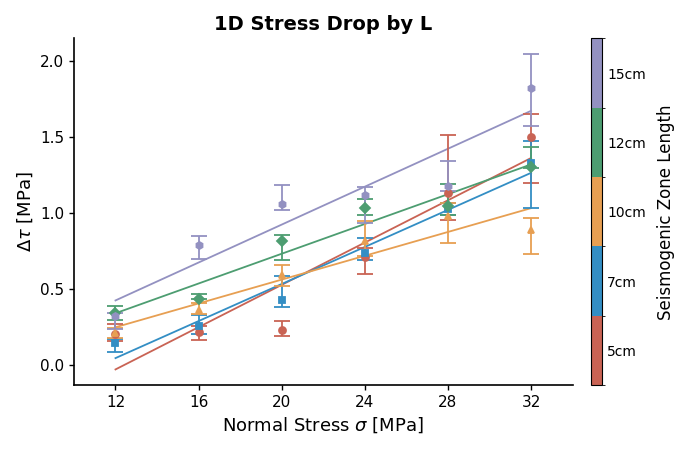

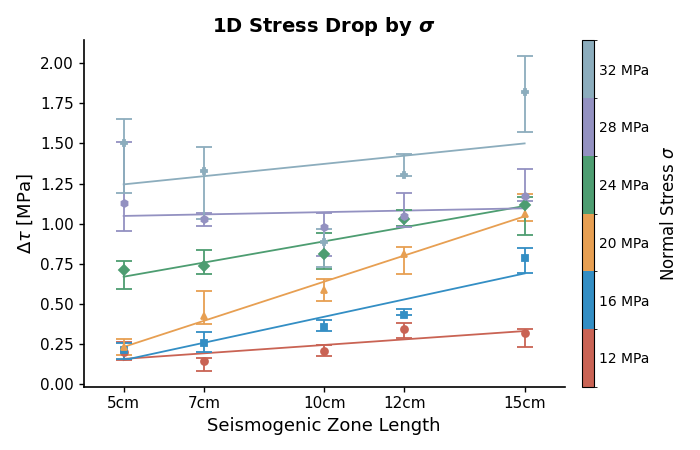

In [5]:
# ========= 5. 繪製 Tau Drop =========
plot_metric('delta_tau', r'1D Stress Drop by L', r'$\Delta\tau$ [MPa]')
# ========= 8. 以群組為 X 軸：Tau Drop =========
plot_metric_by_group('delta_tau', r'1D Stress Drop by $\boldsymbol{\sigma}$', r'$\Delta\tau$ [MPa]')

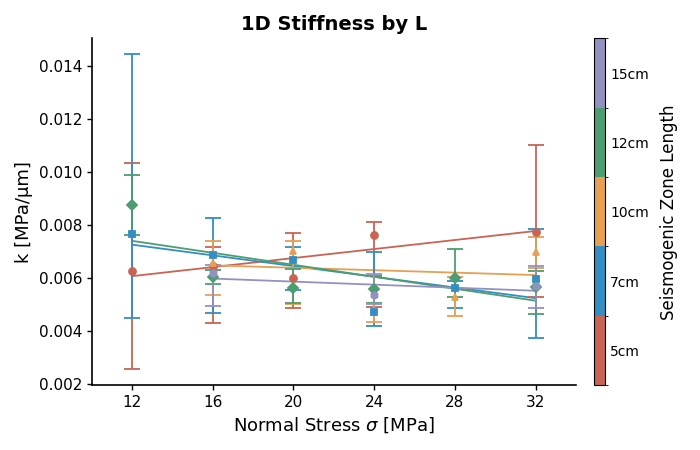

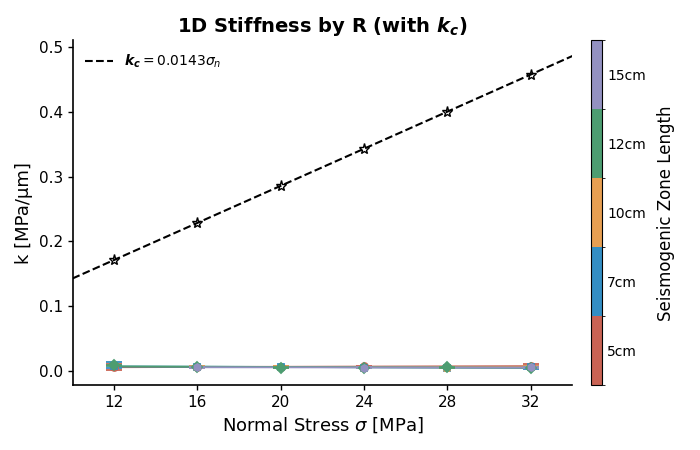

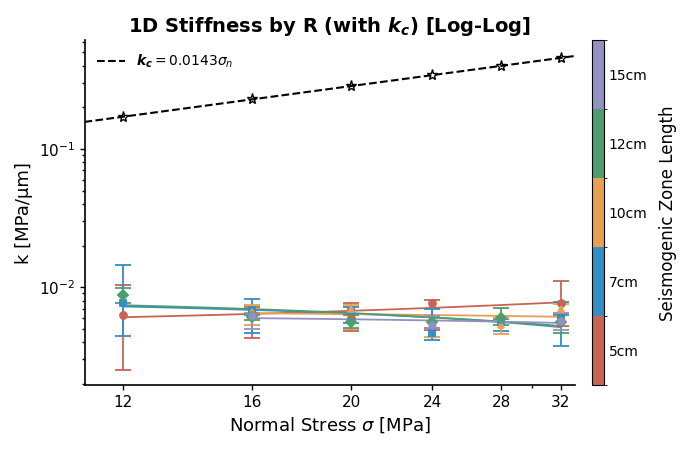

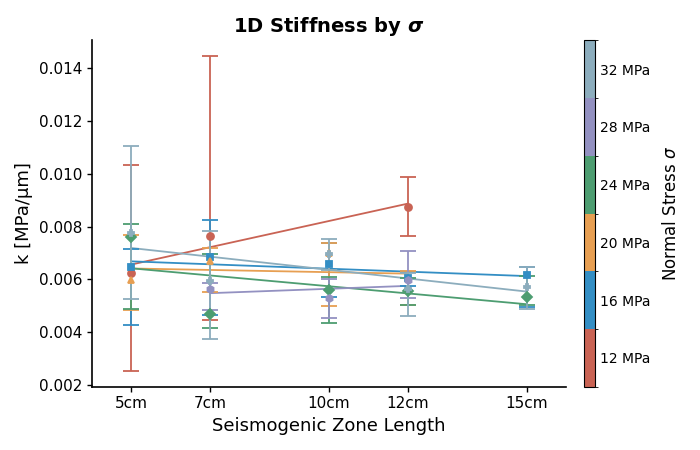

In [6]:
# ========= 6. 繪製 K Stiffness =========
plot_metric('k', r'1D Stiffness by L', 'k [MPa/\u03bcm]')
plot_metric('k', r'1D Stiffness by R (with $\boldsymbol{k}_{\boldsymbol{c}}$)', 'k [MPa/\u03bcm]', show_kc=True)
plot_metric('k', r'1D Stiffness by R (with $\boldsymbol{k}_{\boldsymbol{c}}$) [Log-Log]', 'k [MPa/\u03bcm]', loglog=True, show_kc=True)
# ========= 9. 以群組為 X 軸：K Stiffness =========
plot_metric_by_group('k', r'1D Stiffness by $\boldsymbol{\sigma}$', 'k [MPa/\u03bcm]')



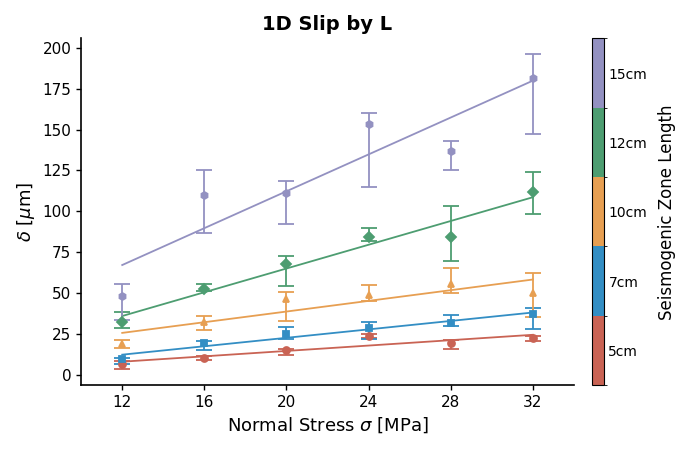

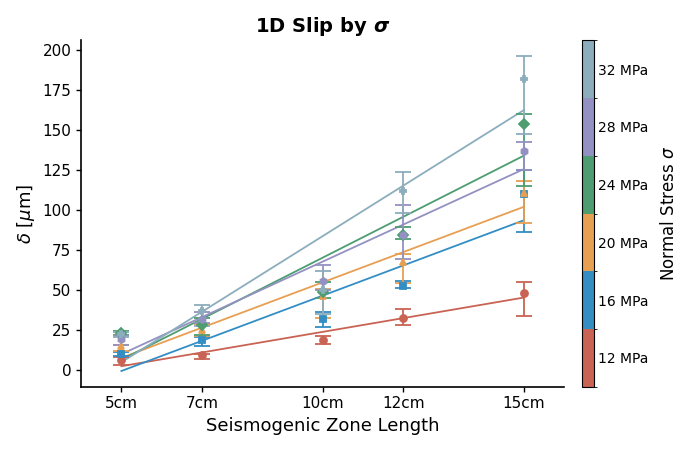

In [7]:
# ========= 7. 繪製 Delta (E2+E3+E4 平均) =========
plot_metric('delta_avg', r'1D Slip by L', r'$\delta$ [$\mu$m]', use_delta=True)
# ========= 10. 以群組為 X 軸：Delta =========
plot_metric_by_group('delta_avg', r'1D Slip by $\boldsymbol{\sigma}$', r'$\delta$ [$\mu$m]', use_delta=True)

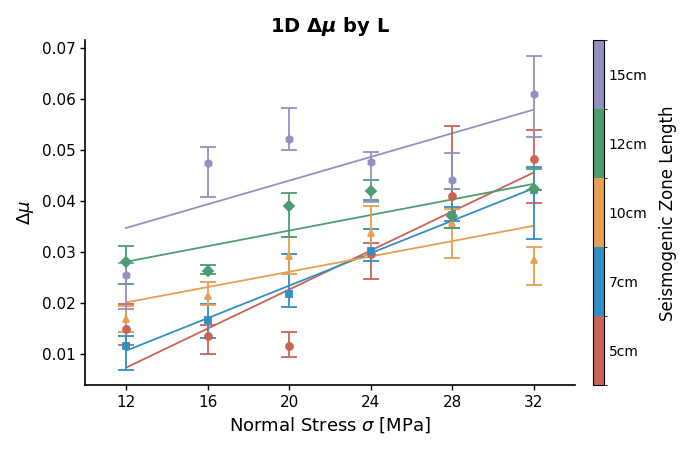

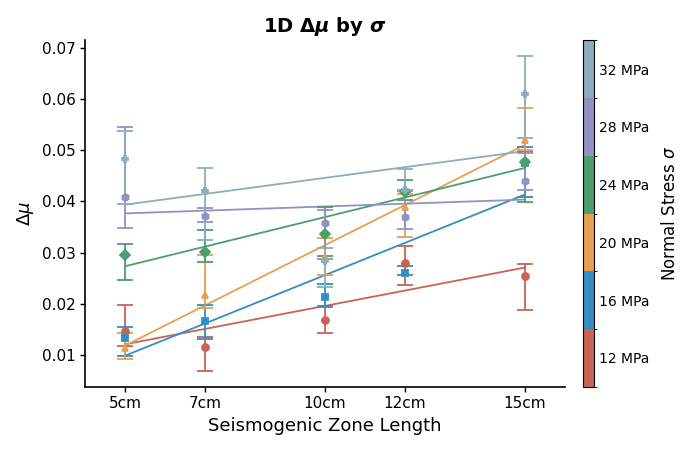

In [8]:
# ========= Delta Mu vs Normal Stress =========
plot_metric('delta_mu', r'1D $\boldsymbol{\Delta\mu}$ by L', r'$\Delta\mu$')
# ========= Delta Mu by Seismogenic Zone Length =========
plot_metric_by_group('delta_mu', r'1D $\boldsymbol{\Delta\mu}$ by $\boldsymbol{\sigma}$', r'$\Delta\mu$')


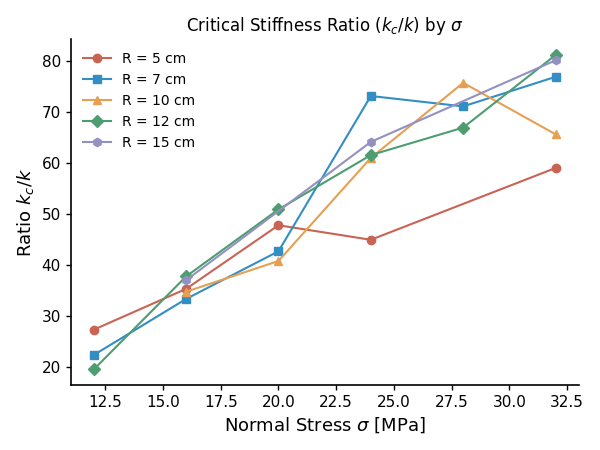

=== Mean kc/k values by Radius and Normal Stress ===
 L (cm)  Normal Stress (MPa)  Mean kc/k
      5              12.0000    27.3803
      5              16.0000    35.3735
      5              20.0000    47.8342
      5              24.0000    44.9895
      5              32.0000    59.0468
      7              12.0000    22.4220
      7              16.0000    33.4011
      7              20.0000    42.7335
      7              24.0000    73.1462
      7              28.0000    71.1128
      7              32.0000    76.8973
     10              16.0000    34.8189
     10              20.0000    40.8387
     10              24.0000    61.0283
     10              28.0000    75.7255
     10              32.0000    65.6488
     12              12.0000    19.5917
     12              16.0000    37.8113
     12              20.0000    50.9385
     12              24.0000    61.5737
     12              28.0000    66.9548
     12              32.0000    81.1645
     15              16.000

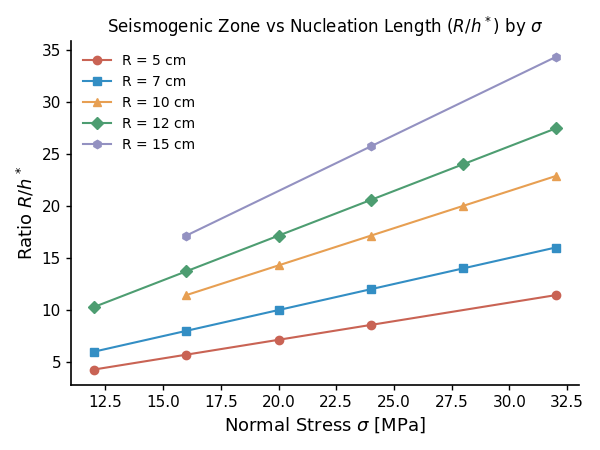

=== R/h* (L/h*) values by Radius and Normal Stress ===
 L (cm)  Normal Stress (MPa)  h* (cm)    L/h*
      5              12.0000   1.1667  4.2857
      5              16.0000   0.8750  5.7143
      5              20.0000   0.7000  7.1429
      5              24.0000   0.5833  8.5714
      5              32.0000   0.4375 11.4286
      7              12.0000   1.1667  6.0000
      7              16.0000   0.8750  8.0000
      7              20.0000   0.7000 10.0000
      7              24.0000   0.5833 12.0000
      7              28.0000   0.5000 14.0000
      7              32.0000   0.4375 16.0000
     10              16.0000   0.8750 11.4286
     10              20.0000   0.7000 14.2857
     10              24.0000   0.5833 17.1429
     10              28.0000   0.5000 20.0000
     10              32.0000   0.4375 22.8571
     12              12.0000   1.1667 10.2857
     12              16.0000   0.8750 13.7143
     12              20.0000   0.7000 17.1429
     12              24.0

In [11]:
# ========= Critical Stiffness Ratio (kc/k) =========
# 1. 取得所有的 stiffness (k) 資料
k_data = process_data('k')

# 準備整理用的 list
ratio_list = []

fig, ax = plt.subplots(figsize=(6, 4.5))
_apply_pub_style(ax)

# 為不同組別定義顏色與標記
for i, exp_data in enumerate(k_data):
    group_val = exp_data['group_val']
    stats = exp_data['stats'].copy()
    
    # kc = 0.01429 * sigma
    stats['kc'] = 0.01429 * stats['sigma']
    # k 是 process_data 取得的 median
    stats['kc_k_ratio'] = stats['kc'] / stats['median']
    
    color = PALETTE[i % len(PALETTE)]
    marker = MARKERS[i % len(MARKERS)]
    
    # 畫出該組的線與點
    ax.plot(stats['sigma'], stats['kc_k_ratio'], color=color, marker=marker, 
            linestyle='-', linewidth=1.5, label=f'R = {group_val} cm',
            markersize=6, alpha=ALPHA)
            
    # 把這組的資料存起來以便列印
    for _, row in stats.iterrows():
        ratio_list.append({
            'L (cm)': group_val,
            'Normal Stress (MPa)': row['sigma'],
            'Mean kc/k': row['kc_k_ratio']
        })

ax.set_xlabel(r'Normal Stress $\sigma$ [MPa]')
ax.set_ylabel(r'Ratio $k_c/k$')
ax.set_title(r'Critical Stiffness Ratio ($k_c/k$) by $\sigma$')
ax.legend(frameon=False, fontsize=10)

plt.tight_layout()
plt.show()

# 2. 列出值 (不畫在圖上)
ratio_df = pd.DataFrame(ratio_list)
print("=== Mean kc/k values by Radius and Normal Stress ===")
print(ratio_df.to_string(index=False, float_format="%.4f"))

# ========= R / h* Ratio =========
# 1. 取得實際有資料的 sigma (沿用 k_data)
k_data = process_data('k')
ratio_list_hstar = []

fig, ax = plt.subplots(figsize=(6, 4.5))
_apply_pub_style(ax)

for i, exp_data in enumerate(k_data):
    group_val = exp_data['group_val']  # R
    stats = exp_data['stats'].copy()
    
    # 計算 h* = 14 / sigma
    stats['h_star'] = 14.0 / stats['sigma']
    # 2D 實驗中，發震區尺寸為半徑 R，因此計算 R / h*
    stats['R_h_ratio'] = group_val / stats['h_star']
    
    color = PALETTE[i % len(PALETTE)]
    marker = MARKERS[i % len(MARKERS)]
    
    ax.plot(stats['sigma'], stats['R_h_ratio'], color=color, marker=marker, 
            linestyle='-', linewidth=1.5, label=f'R = {group_val} cm',
            markersize=6, alpha=ALPHA)
            
    for _, row in stats.iterrows():
        ratio_list_hstar.append({
            'L (cm)': group_val,
            'Normal Stress (MPa)': row['sigma'],
            'h* (cm)': row['h_star'],
            'L/h*': row['R_h_ratio']
        })

ax.set_xlabel(r'Normal Stress $\sigma$ [MPa]')
ax.set_ylabel(r'Ratio $R/h^*$')
ax.set_title(r'Seismogenic Zone vs Nucleation Length ($R/h^*$) by $\sigma$')
ax.legend(frameon=False, fontsize=10)

plt.tight_layout()
plt.show()

# 2. 列出值 (不畫在圖上)
ratio_df_hstar = pd.DataFrame(ratio_list_hstar)
print("=== R/h* (L/h*) values by Radius and Normal Stress ===")
print(ratio_df_hstar.to_string(index=False, float_format="%.4f"))

